## Домашка 3

#### *«Ты понимаешь, что это значит? Это значит, что эта пакость не работает!» — Назад в будущее*

Эта домашка про метрики в a/b-тестировании. За неё можно получить максимум 12 баллов. 

**Дедлайны**  
Мягкий дедлайн: 04.10.2026 23:59 по МСК.   
Жесткий дедлайн: 11.10.2026 23:59 по МСК.  

Штраф за сдачу после мягкого дедлайна: –20% от набранного балла.   
После жесткого дедлайна работы не принимаются.   

**Правила сдачи**   
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.    

**Использование ИИ**
- Использование генеративных моделей для написания кода допустимо при следующих условиях: сгенерированный фрагмент прочитан, адаптирован под условие задачи и данные, вы способны объяснить каждую его строку. Решение, полученное путем передачи модели формулировки задания целиком и прямого копирования ответа в ячейку ноутбука без содержательной переработки, оценивается в 0 баллов за это задание.
- Ответы на текстовые вопросы (описание поведения графика, интерпретация метрики, формулировка гипотез и т.п.) должны быть написаны вами самостоятельно в markdown-ячейках. Использование генеративных моделей для ответа на текстовые вопросы приводит к аннулированию всей работы, а не отдельного задания: интерпретация результатов — главный проверяемый в курсе навык, передача ее ИИ лишает нас возможности оценить, насколько хорошо вы усвоили материал.
- Если генеративная модель использовалась при решении, в конце ноутбука в отдельной markdown-ячейке укажите: номера заданий, при работе над которыми она применялась, использованную модель (с версией) и текст промтов. При обоснованном подозрении на использование ИИ, не отраженное в этом разделе, работа аннулируется целиком независимо от того, к какой части заданий относится подозрение.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета. 
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в ведомости на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_3). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3. 

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.


Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_3_data.zip)

In [600]:
import pandas as pd
import numpy as np
from scipy.stats import norm, pearsonr
import math

### Warm up

#### 1. Сопоставьте тип эксперимента с продуктовым изменением — 2 балла

a) По-юзерный A/B тест  
b) Свитчбек (по времени)   
c) Региональный A/B тест


1. Новая логика выдачи контента на главной в стриминговом сервисе фильмов и сериалов.
2. Запуск динамического ценообразования в сервисе доставки еды.
3. Тестирование push-уведомления о брошенной корзине в e-commerce приложении.
4. Раскатка в сервисе такси через эксперимент новой схемы комиссий для водителей (старт с одного города).
5. Добавление ипотечного калькулятора с точкой входа в Новостройки на главной сервиса объявлений Недвижимости.
6. Изменение SLA времени доставки в сервисе курьерской доставки (старт с одного города).

1-a <br>
2-b <br>
3-a <br>
4-c <br>
5-a <br>
6-c <br>

In [601]:
# your answer is here

### Case Study. Дизайн эксперимента в сервисе объявлений жилой недвижимости 🏡

**Легенда**  
Вы работаете продуктовым аналитиком в сервисе объявлений жилой недвижимости. Платформа позволяет пользователям размещать объявления о продаже и аренде жилья (как частным лицам, так и застройщикам), а другим — просматривать и контактировать / оставлять заявки по объявлениям.    
Ваша команда "Новостройки" хочет разместить на главной ипотечный калькулятор с точкой входа напрямую в свой раздел. Цель — увеличить число заявок.

**Гипотеза** — размещение ипотечного калькулятора на главной сервиса увеличит долю пользователей, оставивших заявку в Новостройках, как минимум на 15%, при этом не ухудшит аналогичные метрики в других разделах (Аренда, Вторичка) более чем на 3%.

$$
\Delta_{\mathrm{rel}}=\left(\frac{p_t-p_c}{p_c}\right)\times 100\% \quad \text{(формула эффекта)}
$$

**Ограничения** — вы не можете держать главную в тесте больше 14 дней из-за запланированного календаря экспериментов с другими командами.

**Набор метрик для дизайна.**   
Target — доля пользователей с заполненной заявкой на звонок (Новостройки).   

Guardrails:
- доля пользователей с контактом по объявлению Аренды;
- доля пользователей с контактом по объявлению Вторички;
- доля пользователей с контактом по объявлению из любой категории (подумайте, зачем нужна эта метрика? от какой ловушки она защищает?).   

Informative:
- доля пользователей, перешедших с главной в раздел Аренды;
- доля пользователей, перешедших с главной в раздел Вторички;
- доля пользователей, перешедших с главной в раздел Новостроек;
- доля пользователей с переходами в список объявлений по навигации на главной.

Все доли рассчитываются от набранного объема пользователей в каждой из групп. Пользователи попадают в exposure сразу при посещении главной.

**Для расчетов метрик используйте следующие ивенты:**
- Для target и guardrails — contact_submit.
- Для informative — list_view и source==main_nav.

*В рамках такого эксперимента также имеет смысл смотреть на среднее число контактов / заявок по каждому из разделов и в общем, а не просто на бинарные метрики. Но в данном задании мы сосредоточимся на долях, чтобы не раздувать алгоритм расчета до полного реалистичного пресета метрик.*

In [602]:
df_logs = pd.read_csv('data/hw_3_events_data.csv')
df_logs.head()

,timestamp,user_id,session_id,event,category,source,listing_id
0,2025-06-01 00:00:00,114227,8828585581,main_view,none,none,NaN
1,2025-06-01 00:00:00,212987,8591655166,main_view,none,none,NaN
2,2025-06-01 00:00:00,1413962,2533393268,add_fav,rent_long,other,992874562.0
3,2025-06-01 00:00:00,1221850,2060698550,main_view,none,none,NaN
4,2025-06-01 00:00:00,31469,6550065912,main_view,none,none,NaN


In [603]:
df_exps = pd.read_csv('data/hw_3_experimens_history.csv')
df_exps.head()

,exp_id,days,target_contact_effect_rel,target_contact_p_value,target_contact_p0,target_contact_effect_abs,proxy_card_effect_rel,proxy_card_p_value,proxy_card_p0,proxy_card_effect_abs,proxy_fav_effect_rel,proxy_fav_p_value,proxy_fav_p0,proxy_fav_effect_abs,proxy_form_effect_rel,proxy_form_p_value,proxy_form_p0,proxy_form_effect_abs
0,3937,7,0.000067,0.448527,0.000382,2.562909e-08,0.000814,0.254909,0.014527,0.000012,0.014880,0.443100,0.004335,0.000065,0.054000,0.200074,0.000782,0.000042
1,2806,7,0.000053,0.353007,0.000339,1.793707e-08,0.025588,0.002390,0.012604,0.000323,0.055000,0.007806,0.004289,0.000236,0.042542,0.077772,0.000687,0.000029
2,3457,7,0.000036,0.397718,0.000353,1.255839e-08,0.010437,0.171633,0.013020,0.000136,0.007892,0.486577,0.004187,0.000033,0.028638,0.385118,0.000718,0.000021
3,1002,7,0.000032,0.266510,0.000388,1.246465e-08,0.015525,0.001215,0.012697,0.000197,0.045051,0.000516,0.004062,0.000183,0.025849,0.164273,0.000735,0.000019
4,9070,7,0.000046,0.461855,0.000377,1.722521e-08,0.011572,0.217843,0.013902,0.000161,0.010127,0.317622,0.004349,0.000044,0.036751,0.236595,0.000786,0.000029


Описание данных hw_3_events_data:

- timestamp — дата-время взаимодействия с контентом
- user_id — уникальный идентификатор пользователя
- session_id – уникальный идентификатор сессии
- event — тип события
- category — категория, в которой произошло событие (не приходит для главной)
- source — источник перехода на страницу
- listing_id – уникальный идентификатор объявления

Описание данных hw_3_experimens_history (это история экспериментов именно в разделе Новостройки):

- exp_id — уникальный идентификатор эксперимента
- days — длительность теста
- target_contact_effect_rel — относительный эффект на таргет метрике
- target_contact_p_value — p-value полученного результата для таргет метрики
- target_contact_p0 — значение конверсии таргет метрики в контроле
- target_contact_effect_abs — абсолютный эффект на таргет метрике
- proxy_card_effect_rel — относительный эффект на конверсии просмотра карточки объявления
- proxy_card_p_value — p-value полученного результата для конверсии просмотра карточки объявления
- proxy_card_p0 — значение конверсии просмотра карточки объявления в контроле
- proxy_card_effect_abs — абсолютный эффект на конверсии просмотра карточки объявления
- proxy_fav_effect_rel — относительный эффект на конверсии добавления объявления в избранное
- proxy_fav_p_value — p-value полученного результата для конверсии добавления объявления в избранное
- proxy_fav_p0 — значение конверсии добавления объявления в избранное в контроле
- proxy_fav_effect_abs – абсолютный эффект на конверсии добавления объявления в избранное
- proxy_form_effect_rel — относительный эффект на конверсии открытия формы заявки на звонок по объявлению
- proxy_form_p_value — p-value полученного результата для конверсии открытия формы заявки на звонок по объявлению
- proxy_form_p0 — значение конверсии открытия формы заявки на звонок по объявлению в контроле
- proxy_form_effect_abs — абсолютный эффект на конверсии открытия формы заявки на звонок по объявлению

#### 2. Рассчитайте количество дней, необходимое для детектирования заявленных в гипотезе эффектов (target и guardrails-метрики) — 2 балла
Здесь и далее используйте для расчетов значение alpha = 0.01 (делаем поправку на принятие решения по набору метрик) и beta = 0.2. А также двусторонний критерий — мы заранее не знаем, куда двинутся метрики, поэтому хотим учесть и противоположные эффекты.  

Для метрики "доля пользователей с контактом по объявлению из любой категории" также используйте эффект в 3%.

In [604]:
# your code is here
#Смотрю на уникальные значения некоторых полей:
df_logs.event.unique()

array(['main_view', 'add_fav', 'nav_to_category', 'card_view',
       'list_view', 'contact_submit', 'form_start'], dtype=object)

In [605]:
df_logs.category.unique()

array(['none', 'rent_long', 'secondary', 'newbuilds', 'rent_daily'],
      dtype=object)

In [606]:
df_logs.source.unique()

array(['none', 'other', 'main_nav'], dtype=object)

In [607]:
#привожу поле timestamp к отображению даты и сотрирую датафрейм, чтобы легче было проверять расчеты:
df_logs['date']=pd.to_datetime(df_logs['timestamp']).dt.date
df_logs.drop('timestamp', axis=1, inplace=True)
df_logs=df_logs.sort_values(by=['date', 'user_id', 'session_id'])

In [608]:
target = "доля пользователей с заполненной заявкой на звонок (Новостройки)"
guardrail_1 = "доля пользователей с контактом по объявлению Аренды"
guardrail_2 = "доля пользователей с контактом по объявлению Вторички"
guardrail_3 = "доля пользователей с контактом по объявлению из любой категории"

In [609]:
#Функция для расчета количества пользователей, которые совершают действие, подходящее для каждой из метрик:
def get_daily_event_users(df, metric):

    if metric== 'target':
        daily_event_users=df[(df['event']=='contact_submit') & (df['category'] == 'newbuilds')].groupby('date').user_id.nunique()
    
    elif metric== "guardrail_1":
        daily_event_users=df[(df['event']=='contact_submit') & (df['category'].isin(['rent_long', 'rent_daily']))].groupby('date').user_id.nunique()

    elif metric== "guardrail_2":
        daily_event_users=df[(df['event']=='contact_submit') & (df['category'] == 'secondary')].groupby('date').user_id.nunique()

    elif metric== "guardrail_3":
        daily_event_users=df[(df['event']=='contact_submit')].groupby('date').user_id.nunique()
    
    return daily_event_users

In [610]:
#Функция для расчета количества пользователей, которые заходят на сайт:
def get_daily_exposure(df, metric):

    if metric in ['target', "guardrail_1",  "guardrail_2", "guardrail_3"]:
        daily_exposure=df[df['event']=="main_view"].groupby('date').user_id.nunique()
        
    else: None
    return daily_exposure

In [611]:
#Функция расчета количества дней, которые потребуются чтобы задетектировать эффект в эксперименте:
def get_experiment_days(df, metric, expected_effect, alpha, beta):
    
    daily_exposure=get_daily_exposure(df, metric)
    daily_event_user=get_daily_event_users(df, metric)
    
    #конверсия в контрольной группе:
    p_control=sum(daily_event_user)/sum(daily_exposure)

    #эффект, который мы хотим задетектировать:
    mde=p_control*(expected_effect/100)

    z_alpha=norm.ppf(1-alpha/2)
    z_beta=norm.ppf(1-beta)

    #количество пользоватлей для одной группы:
    n=(2*p_control*(1-p_control)*(z_alpha+z_beta)**2)/(mde)**2

    #так как группы две: контрольная и тестовая, то количество дней будет:
    experiment_days = np.ceil(2 * n / daily_exposure.mean())

    return experiment_days

In [612]:
target_experiment_days=get_experiment_days(df_logs, metric='target', expected_effect=15, alpha=0.01, beta=0.2)
print(f'Кол-во дней для метрики - {target}: ', target_experiment_days)

Кол-во дней для метрики - доля пользователей с заполненной заявкой на звонок (Новостройки):  44.0


In [613]:
guardrail_1_experiment_days=get_experiment_days(df_logs, 'guardrail_1', -3, 0.01, 0.2)
print(f'Кол-во дней для метрики - {guardrail_1}: ', guardrail_1_experiment_days)

Кол-во дней для метрики - доля пользователей с контактом по объявлению Аренды:  10.0


In [614]:
guardrail_2_experiment_days=get_experiment_days(df_logs, 'guardrail_2', -3, 0.01, 0.2)
print(f'Кол-во дней для метрики - {guardrail_2}: ', guardrail_2_experiment_days)

Кол-во дней для метрики - доля пользователей с контактом по объявлению Вторички:  28.0


In [615]:
guardrail_3_experiment_days=get_experiment_days(df_logs, 'guardrail_3', -3, 0.01, 0.2)
print(f'Кол-во дней для метрики - {guardrail_3}: ', guardrail_3_experiment_days)

Кол-во дней для метрики - доля пользователей с контактом по объявлению из любой категории:  7.0


**Чтобы увидеть заданные эффект на таргете, требуется 44 дня, что не удовлетворяет ограничению теста.** <br>
**Метрика - доля пользователей с контактом по объявлением из любой категории, на мой взгляд, была добавлена как защитная от падения конверсии в оставление заявки в целом по сервису.**

#### 3. Рассчитайте MDE для информативных метрик — 2 балла
В реальности эффекты по информативным критериям, которые мы также хотим включать в пресет метрик, нужно сравнивать на достижимость на основе прошлых экспериментов. Как правило, проделав это упражнение один раз, вы просто сохраняете достижимый трешхолд в базе знаний команды и принимаете решение о включении их в базовый набор. Проверка эффектов для каждого теста не требуется. Однако, стоит делать периодический пересмотр зафиксированных достижимых эффектов, например раз в полгода / год, или при сильных изменениях продукта / рынка.

В данном задании мы с вами не будем опираться на историю тестов, просто потренируемся делать обратный расчет — размера эффекта от заданной длительности (14 дней).

*Для числителя используйте только ивенты с источником main_nav*

In [616]:

informative_1 = "доля пользователей, перешедших с главной в раздел Аренды"
informative_2 = "доля пользователей, перешедших с главной в раздел Вторички"
informative_3 = "доля пользователей, перешедших с главной в раздел Новостроек"
informative_4 = "доля пользователей с переходами в список объявлений по навигации на главной"

In [617]:
#добавляю в существующую функцию расчет количества пользователей для новых метрик:
def get_daily_event_users(df, metric):

    if metric== 'target':
        daily_event_users=df[(df['event']=='contact_submit') & (df['category'] == 'newbuilds')].groupby('date').user_id.nunique()
    
    elif metric== "guardrail_1":
        daily_event_users=df[(df['event']=='contact_submit') & (df['category'].isin(['rent_long', 'rent_daily']))].groupby('date').user_id.nunique()

    elif metric== "guardrail_2":
        daily_event_users=df[(df['event']=='contact_submit') & (df['category'] == 'secondary')].groupby('date').user_id.nunique()

    elif metric== "guardrail_3":
        daily_event_users=df[(df['event']=='contact_submit')].groupby('date').user_id.nunique()

    elif metric== 'informative_1':
        daily_event_users=df[(df['event']=='list_view') &
        (df['source'] == 'main_nav') & (df['category'].isin(['rent_long', 'rent_daily']))].groupby('date').user_id.nunique()
    
    elif metric== "informative_2":
        daily_event_users=df[(df['event']=='list_view') &
        (df['source'] == 'main_nav') & (df['category']=='secondary')].groupby('date').user_id.nunique()

    elif metric== "informative_3":
        daily_event_users=df[(df['event']=='list_view') &
        (df['source'] == 'main_nav') & (df['category']=='newbuilds')].groupby('date').user_id.nunique()

    elif metric== "informative_4":
        daily_event_users=df[(df['event']=='list_view') &
        (df['source'] == 'main_nav')].groupby('date').user_id.nunique()
    
    return daily_event_users

In [618]:
#также добавляю метрик и в расчет количества пользователей, которые заходят на сайт:
def get_daily_exposure(df, metric):

    if metric in ['target', "guardrail_1",  "guardrail_2", "guardrail_3", 'informative_1', 'informative_2', 'informative_3', 'informative_4']:
        daily_exposure=df[df['event']=="main_view"].groupby('date').user_id.nunique()

    else: None
    return daily_exposure

In [619]:
#функция расчета mde. 
def get_mde(df, metric, experiment_days, alpha, beta):

    daily_exposure=get_daily_exposure(df, metric)
    daily_event_users=get_daily_event_users(df, metric)

    #текущая конверсия в целевое действие по метрике:
    p_control=sum(daily_event_users)/sum(daily_exposure)

    z_alpha=norm.ppf(1-alpha/2)
    z_beta=norm.ppf(1-beta)

    #доступное количество пользователей для заданного количеста дней эксперимента:
    available_n=daily_exposure.mean()*experiment_days/2

    #тогда mde:
    mde=((2*p_control*(1-p_control)*(z_alpha+z_beta)**2)/available_n)**0.5
    return mde

In [620]:
mde_inf_1=get_mde(df_logs, 'informative_1', experiment_days=14, alpha=0.01, beta=0.2)*100
print(f"mde для метрики - {informative_1}: ", mde_inf_1)

mde для метрики - доля пользователей, перешедших с главной в раздел Аренды:  0.14035763980501992


In [621]:
mde_inf_2=get_mde(df_logs, 'informative_2', experiment_days=14, alpha=0.01, beta=0.2)*100
print(f"mde для метрики - {informative_2}: ", mde_inf_2)

mde для метрики - доля пользователей, перешедших с главной в раздел Вторички:  0.10480597996701609


In [622]:
mde_inf_3=get_mde(df_logs, 'informative_3', experiment_days=14, alpha=0.01, beta=0.2)*100
print(f"mde для метрики - {informative_3}: ", mde_inf_3)

mde для метрики - доля пользователей, перешедших с главной в раздел Новостроек:  0.047006557160001114


In [623]:
mde_inf_4=get_mde(df_logs, 'informative_4', experiment_days=14, alpha=0.01, beta=0.2)*100
print(f"mde для метрики - {informative_4}: ", mde_inf_4)

mde для метрики - доля пользователей с переходами в список объявлений по навигации на главной:  0.1573146244032923


#### 4. Выбираем proxy-метрику (шаг 1) — 2 балла
Стало понятно, что за 14 дней мы не успеем замерить эффект по таргету. Что делать? Можно использовать методы снижения дисперсии, а можно попробовать подобрать proxy-метрику. Давайте реализуем второй вариант.

**Для proxy будем использовать 3-х кандидатов:**
- доля пользователей с просмотром карточки объявления в Новостройках;
- доля пользователей, добавивших в избранное объявление в Новостройках;
- доля пользователей, открывших форму заявки в Новостройках — связь с автором объявления в этом разделе предполагает обратный звонок от офиса продаж, поэтому чтобы сделать событие контакта, релевантное другим разделам, нужно ввести свой номер телефона в форму заявки, расположенную на карточке.

Для каждой из proxy-метрик:
- Рассчитайте MDE для заданной длительности — 14 дней;
- По историческому набору экспериментов постройте диаграмму рассеяния зафиксированных эффектов и длительности тестов (пометьте значимые эффекты).

**Для расчетов метрик используйте следующие ивенты:**
- Для proxy — card_view, add_fav, form_start.

In [624]:

proxy_1 = "доля пользователей с просмотром карточки объявления в Новостройках"
proxy_2 = "доля пользователей, добавивших в избранное объявление в Новостройках"
proxy_3 = "доля пользователей, открывших форму заявки в Новостройках"

In [625]:
def get_daily_event_users(df, metric):
    if metric== 'target':
        daily_event_users=df[(df['event']=='contact_submit') & (df['category'] == 'newbuilds')].groupby('date').user_id.nunique()
    
    elif metric== "guardrail_1":
        daily_event_users=df[(df['event']=='contact_submit') & (df['category'].isin(['rent_long', 'rent_daily']))].groupby('date').user_id.nunique()

    elif metric== "guardrail_2":
        daily_event_users=df[(df['event']=='contact_submit') & (df['category'] == 'secondary')].groupby('date').user_id.nunique()

    elif metric== "guardrail_3":
        daily_event_users=df[(df['event']=='contact_submit')].groupby('date').user_id.nunique()

    elif metric== 'informative_1':
        daily_event_users=df[(df['event']=='list_view') &
        (df['source'] == 'main_nav') & (df['category'].isin(['rent_long', 'rent_daily']))].groupby('date').user_id.nunique()
    
    elif metric== "informative_2":
        daily_event_users=df[(df['event']=='list_view') &
        (df['source'] == 'main_nav') & (df['category']=='secondary')].groupby('date').user_id.nunique()

    elif metric== "informative_3":
        daily_event_users=df[(df['event']=='list_view') &
        (df['source'] == 'main_nav') & (df['category']=='newbuilds')].groupby('date').user_id.nunique()

    elif metric== "informative_4":
        daily_event_users=df[(df['event']=='list_view') &
        (df['source'] == 'main_nav')].groupby('date').user_id.nunique()

    elif metric== "proxy_1":
        daily_event_users=df[(df['event']=='card_view') & (df['category']=='newbuilds')].groupby('date').user_id.nunique()

    elif metric== "proxy_2":
        daily_event_users=df[(df['event']=='add_fav') & (df['category']=='newbuilds')].groupby('date').user_id.nunique()

    elif metric== "proxy_3":
        daily_event_users=df[(df['event']=='form_start') &  (df['category']=='newbuilds')].groupby('date').user_id.nunique()

    
    return daily_event_users

In [626]:
def get_daily_exposure(df, metric):

    if metric in ['target', "guardrail_1",  "guardrail_2", "guardrail_3", 'informative_1', 'informative_2', 'informative_3', 'informative_4']:
        daily_exposure=df[df['event']=="main_view"].groupby('date').user_id.nunique()

    elif metric in ['proxy_1', 'proxy_2', 'proxy_3']:
        daily_exposure=df[(df['event']=='list_view') & (df['source'] == 'main_nav') & (df['category']=='newbuilds')].groupby('date').user_id.nunique()

        
    return daily_exposure

In [627]:
mde_proxy_1=get_mde(df_logs, 'proxy_1', experiment_days=14, alpha=0.01, beta=0.2)*100
print(f"mde для метрики - {proxy_1}: ", mde_proxy_1)

mde для метрики - доля пользователей с просмотром карточки объявления в Новостройках:  1.1044345473149693


In [628]:
mde_proxy_2=get_mde(df_logs, 'proxy_2', experiment_days=14, alpha=0.01, beta=0.2)*100
print(f"mde для метрики - {proxy_2}: ", mde_proxy_2)

mde для метрики - доля пользователей, добавивших в избранное объявление в Новостройках:  0.6788149828017048


In [629]:
mde_proxy_3=get_mde(df_logs, 'proxy_3', experiment_days=14, alpha=0.01, beta=0.2)*100
print(f"mde для метрики - {proxy_3}: ", mde_proxy_3)

mde для метрики - доля пользователей, открывших форму заявки в Новостройках:  0.3001482056033429


In [630]:
#дата сет для построения диаграммы рассеяния:
exps_significant=df_exps[['exp_id', 'days','proxy_card_effect_rel', 'proxy_card_p_value', 'proxy_fav_effect_rel', 'proxy_fav_p_value','proxy_form_effect_rel','proxy_form_p_value']].copy()

In [631]:
alpha=0.01
exps_significant['card_significant'] = np.where(exps_significant['proxy_card_p_value'] < alpha,'Значимый','Незначимый')
exps_significant['fav_significant']=np.where(exps_significant['proxy_fav_p_value'] < alpha,'Значимый','Незначимый')
exps_significant['form_significant']=np.where(exps_significant['proxy_form_p_value'] < alpha,'Значимый','Незначимый')

In [632]:
exps_significant.head()

,exp_id,days,proxy_card_effect_rel,proxy_card_p_value,proxy_fav_effect_rel,proxy_fav_p_value,proxy_form_effect_rel,proxy_form_p_value,card_significant,fav_significant,form_significant
0,3937,7,0.000814,0.254909,0.014880,0.443100,0.054000,0.200074,Незначимый,Незначимый,Незначимый
1,2806,7,0.025588,0.002390,0.055000,0.007806,0.042542,0.077772,Значимый,Значимый,Незначимый
2,3457,7,0.010437,0.171633,0.007892,0.486577,0.028638,0.385118,Незначимый,Незначимый,Незначимый
3,1002,7,0.015525,0.001215,0.045051,0.000516,0.025849,0.164273,Значимый,Значимый,Незначимый
4,9070,7,0.011572,0.217843,0.010127,0.317622,0.036751,0.236595,Незначимый,Незначимый,Незначимый


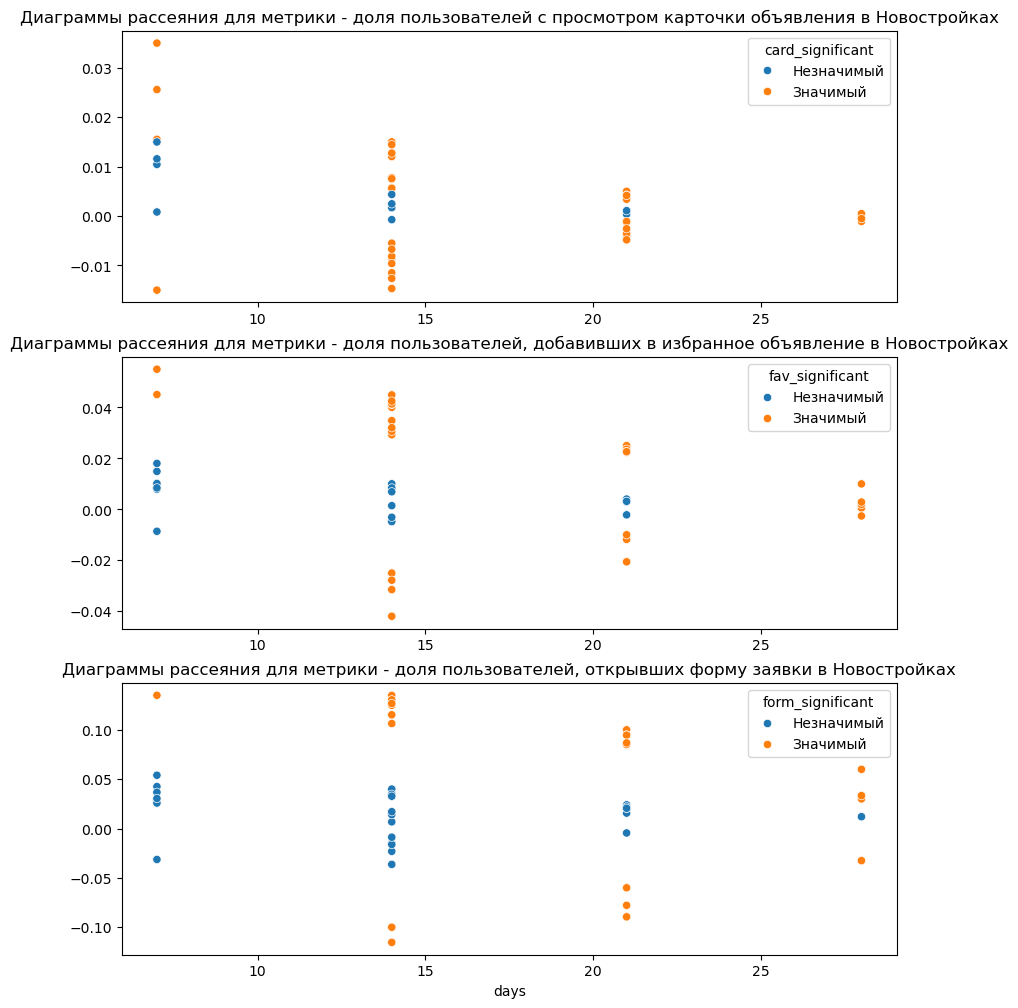

In [633]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3,1, figsize=(10,12))

sns.scatterplot(data=exps_significant, x='days', y='proxy_card_effect_rel', hue='card_significant', ax=ax[0])
ax[0].set_title(f'Диаграммы рассеяния для метрики - {proxy_1}')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
sns.scatterplot(data=exps_significant, x='days', y='proxy_fav_effect_rel', hue='fav_significant', ax=ax[1])
ax[1].set_title(f'Диаграммы рассеяния для метрики - {proxy_2}')
ax[1].set_xlabel('')
ax[1].set_ylabel('')
sns.scatterplot(data=exps_significant, x='days', y='proxy_form_effect_rel', hue='form_significant', ax=ax[2])
ax[2].set_title(f'Диаграммы рассеяния для метрики - {proxy_3}')
ax[2].set_ylabel('')


plt.show()

#### 5. Выбираем proxy-метрику (шаг 2) — 2 балла
Для каждой из proxy-метрик по историческому набору экспериментов рассчитайте:
- Binary Sensitivity;
- MSE с таргет-метрикой;
- Корреляцию Пирсона с таргет-метрикой.

In [634]:
# your code is here
#Расчет Binary Sensitivity:

alpha=0.01
target_sensitivity = (df_exps['target_contact_p_value'] < alpha).sum()/ len(df_exps['target_contact_p_value'])
proxy_card_sensitivity=(df_exps['proxy_card_p_value'] < alpha).sum()/ len(df_exps['proxy_card_p_value'])
proxy_fav_sensitivity=(df_exps['proxy_fav_p_value'] < alpha).sum()/ len(df_exps['proxy_fav_p_value'])
proxy_form_sensitivity=(df_exps['proxy_form_p_value'] < alpha).sum()/ len(df_exps['proxy_form_p_value'])

print(f' sensitivity метрики {target}:    ', target_sensitivity, '\n', f'sensitivity метрики {proxy_1}', proxy_card_sensitivity, '\n',
     f'sensitivity метрики {proxy_2}', proxy_fav_sensitivity, '\n', f'sensitivity метрики {proxy_3}', proxy_form_sensitivity )

 sensitivity метрики доля пользователей с заполненной заявкой на звонок (Новостройки):     0.4 
 sensitivity метрики доля пользователей с просмотром карточки объявления в Новостройках 0.8 
 sensitivity метрики доля пользователей, добавивших в избранное объявление в Новостройках 0.64 
 sensitivity метрики доля пользователей, открывших форму заявки в Новостройках 0.46


In [635]:
#Расчет MSE:
mse_proxy_card = np.mean((df_exps['proxy_card_effect_rel'] - df_exps['target_contact_effect_rel']) ** 2)
mse_proxy_fav = np.mean((df_exps['proxy_fav_effect_rel'] - df_exps['target_contact_effect_rel']) ** 2)
mse_proxy_form = np.mean((df_exps['proxy_form_effect_rel'] - df_exps['target_contact_effect_rel']) ** 2)
print(f' mse метрики {proxy_1}: ', np.round(mse_proxy_card,3), '\n', f'mse метрики {proxy_2}:  ', np.round(mse_proxy_fav,3), '\n', 
      f'mse метрики {proxy_3}: ', np.round(mse_proxy_form, 3))

 mse метрики доля пользователей с просмотром карточки объявления в Новостройках:  0.014 
 mse метрики доля пользователей, добавивших в избранное объявление в Новостройках:   0.011 
 mse метрики доля пользователей, открывших форму заявки в Новостройках:  0.007


In [636]:
#Расчет корреляции Пирсона:

corr_proxy_card=df_exps['target_contact_effect_rel'].corr(df_exps['proxy_card_effect_rel'])
corr_proxy_fav=df_exps['target_contact_effect_rel'].corr(df_exps['proxy_fav_effect_rel'])
corr_proxy_form=df_exps['target_contact_effect_rel'].corr(df_exps['proxy_form_effect_rel'])

print(f' корреляция таргета с метрикой - {proxy_1}: ', np.round(corr_proxy_card,3), '\n', f'корреляция таргета с метрикой - {proxy_2}:  ', np.round(corr_proxy_fav,3), '\n', 
     f'корреляция таргета с метрикой - {proxy_3}: ', np.round(corr_proxy_form, 3))

 корреляция таргета с метрикой - доля пользователей с просмотром карточки объявления в Новостройках:  0.15 
 корреляция таргета с метрикой - доля пользователей, добавивших в избранное объявление в Новостройках:   0.67 
 корреляция таргета с метрикой - доля пользователей, открывших форму заявки в Новостройках:  0.724


#### 6. Выбираем proxy-метрику (шаг 3) — 2 балла
Для каждой из proxy-метрик по историческому набору экспериментов:
- Рассчитайте Proxy Score;
- Выведите матрицу согласия-несогласия знаков с таргет-метрикой.

Выберите proxy, с которой вы пойдете в а/б тест, обоснуйте выбор.

In [637]:
#Функция для расчета Proxy Score:
def get_proxy_score(df, proxy_effect_rel, alpha):
    #1. Считаю количество экспериментов, в которых таргет < alpha
    singnificant_target=sum(df['target_contact_p_value']<alpha) 

    #2. Отбираю эксперименты, в которых и таргет и проксиметрика значимы
    both_significant=df[(df['target_contact_p_value']<alpha) & (df[proxy_effect_rel]<alpha)][['target_contact_effect_rel', proxy_effect_rel]]

    #3.Считаю detections
    detections=(np.sign(both_significant['target_contact_effect_rel']) == np.sign(both_significant[proxy_effect_rel])).sum()

    #4.Считаю ошибки
    mistakes=(np.sign(both_significant['target_contact_effect_rel']) != np.sign(both_significant[proxy_effect_rel])).sum()

    proxy_score=(detections-mistakes)/singnificant_target

    return proxy_score

In [638]:
proxy_card_score=get_proxy_score(df_exps, 'proxy_card_effect_rel', alpha=0.01)
proxy_fav_score=get_proxy_score(df_exps, 'proxy_fav_effect_rel', alpha=0.01)
proxy_form_score=get_proxy_score(df_exps, 'proxy_form_effect_rel', alpha=0.01)

print (f' proxy score метрики - {proxy_1}: ', proxy_card_score,'\n', f'proxy score метрики - {proxy_2}:  ', proxy_fav_score,'\n',f'proxy score метрики - {proxy_3}: ', proxy_form_score )

 proxy score метрики - доля пользователей с просмотром карточки объявления в Новостройках:  0.15 
 proxy score метрики - доля пользователей, добавивших в избранное объявление в Новостройках:   0.35 
 proxy score метрики - доля пользователей, открывших форму заявки в Новостройках:  0.1


**Проксиметрика "доля пользователей, добавивших в избранное объявление в Новостройках" наиболее согласуется с движением таргета по методу расчету Proxy Score.**

In [639]:
#Функция для расчета значений в матрице знаков:
def get_proxy_martix_signs(df, proxy_effect_rel, alpha):

    #1. Отбираю эксперименты, в которых и таргет и проксиметрика значимы
    both_significant=df[(df['target_contact_p_value']<alpha) & (df[proxy_effect_rel]<alpha)][['target_contact_effect_rel', proxy_effect_rel]]

    #3.Определяю знак эффекта у таргета и прокси метрики:
    target_sign=np.sign(both_significant['target_contact_effect_rel'])
    proxy_sign= np.sign(both_significant[proxy_effect_rel])

    matrix=pd.crosstab(target_sign, proxy_sign)

    return matrix

In [640]:
proxy_card_matrix_signs=get_proxy_martix_signs(df_exps, 'proxy_card_effect_rel', alpha=0.01)
proxy_card_matrix_signs

proxy_card_effect_rel,-1.0,1.0
target_contact_effect_rel,,
-1.0,2,0
1.0,7,8


In [641]:
proxy_fav_matrix_signs=get_proxy_martix_signs(df_exps, 'proxy_fav_effect_rel', alpha=0.01)
proxy_fav_matrix_signs

proxy_fav_effect_rel,-1.0,1.0
target_contact_effect_rel,,
-1.0,2,0
1.0,0,5


In [642]:
proxy_form_matrix_signs=get_proxy_martix_signs(df_exps, 'proxy_form_effect_rel', alpha=0.01)
proxy_form_matrix_signs

proxy_form_effect_rel,-1.0
target_contact_effect_rel,
-1.0,2


**Вывод: в качестве прокси метрику я бы выбрала долю пользователей, добавивших в избранное объявление в Новостройках, так как** <br>
**- у нее наибольшие proxy score среди всех метрик;**<br>
**- нет расхождений с таргетом по матрице согласия знаков и при этом количество тестов больше, чем у доли пользователей, открывших форму заявки в Новостройках;**<br>
**- и по всем остальным параметрам такими как mde, чувствительность, корреляция с таргетом и mse она прочно находится на втором месте среди представленных метрик.**